# Cheat sheet: pick your bootstrap

A scannable reference for choosing a `tsbootstrap` method. The capability
table below is built from the library's own metadata, so it cannot drift
from the code. The decision tree summarizes when each family applies.

For the programmatic version of this table, see `diagnose`, which inspects
your data and recommends methods. For the worked rationale behind each
choice, see the which-bootstrap-when tutorial.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## The capability table

One row per method, read straight from `tsbootstrap.metadata.METHODS` and the
spec classes in `tsbootstrap.methods`. The block-length column reports the
actual parameter name on each spec (most use `block_length`; the stationary
bootstrap uses `avg_block_length`; model-based methods have none).

In [2]:
import pandas as pd

from tsbootstrap.metadata import METHODS
from tsbootstrap.methods import OBSERVATION_RESAMPLING


def block_length_param(spec_type):
    """Return the block-length field name on a spec, or None if it has none."""
    fields = getattr(spec_type, "model_fields", {})
    for name in fields:
        if "block_length" in name:
            return name
    return None


def recommended_for(meta, is_resampler):
    """Distill a one-line use case from assumptions and failure modes."""
    if not meta.preserves_temporal_dependence:
        return "i.i.d. data with no serial dependence; baseline"
    if is_resampler:
        return "stationary, weakly dependent series; distribution-free"
    return "series well described by a fitted AR/ARIMA/VAR model"


rows = []
for spec_type, meta in METHODS.items():
    is_resampler = spec_type in OBSERVATION_RESAMPLING
    # Resamplers reuse observed values, so they preserve the empirical marginal.
    # Model-based methods regenerate from fitted dynamics, so their marginal is
    # model-implied rather than empirical.
    marginal = "empirical" if is_resampler else "model-implied"
    rows.append(
        {
            "method": meta.name,
            "spec": spec_type.__name__,
            "serial dependence": "yes" if meta.preserves_temporal_dependence else "no",
            "marginal": marginal,
            "block-length param": block_length_param(spec_type) or "none",
            "wraps around": "yes" if spec_type.__name__ == "CircularBlock" else "no",
            "multivariate": "yes" if meta.supports_multivariate else "no",
            "OOB": "yes" if meta.supports_oob else "no",
            "recommended for": recommended_for(meta, is_resampler),
        }
    )

table = pd.DataFrame(rows).set_index("method")
table

,spec,serial dependence,marginal,block-length param,wraps around,multivariate,OOB,recommended for
method,,,,,,,,
iid,IID,no,empirical,none,no,yes,yes,i.i.d. data with no serial dependence; baseline
moving_block,MovingBlock,yes,empirical,block_length,no,yes,yes,"stationary, weakly dependent series; distribut..."
circular_block,CircularBlock,yes,empirical,block_length,yes,yes,yes,"stationary, weakly dependent series; distribut..."
stationary_block,StationaryBlock,yes,empirical,avg_block_length,no,yes,yes,"stationary, weakly dependent series; distribut..."
non_overlapping_block,NonOverlappingBlock,yes,empirical,block_length,no,yes,yes,"stationary, weakly dependent series; distribut..."
tapered_block,TaperedBlock,yes,empirical,block_length,no,yes,yes,"stationary, weakly dependent series; distribut..."
residual,ResidualBootstrap,yes,model-implied,none,no,yes,no,series well described by a fitted AR/ARIMA/VAR...
sieve_ar,SieveAR,yes,model-implied,none,no,no,no,series well described by a fitted AR/ARIMA/VAR...


Reading the columns:

- **serial dependence**: whether the method preserves temporal structure.
  Only `iid` does not.
- **marginal**: block and i.i.d. methods resample observed values, so the
  one-dimensional marginal is the empirical one. Model-based methods
  regenerate data from fitted dynamics, so their marginal is whatever the
  model implies, not the raw empirical distribution.
- **block-length param**: the constructor argument controlling block size.
  Pass `"auto"` to let the Politis-White rule pick it.
- **wraps around**: only `CircularBlock` wraps blocks past the series end,
  which removes the edge bias of plain moving blocks.
- **OOB**: whether out-of-bag masks are defined, which the EnbPI
  uncertainty layer needs.

## The decision tree

The first split is whether the data has serial dependence. If not, use `IID`. If it does, choose between a block family
(distribution-free, resamples observed values) and a model-based family
(regenerates from a fitted model).

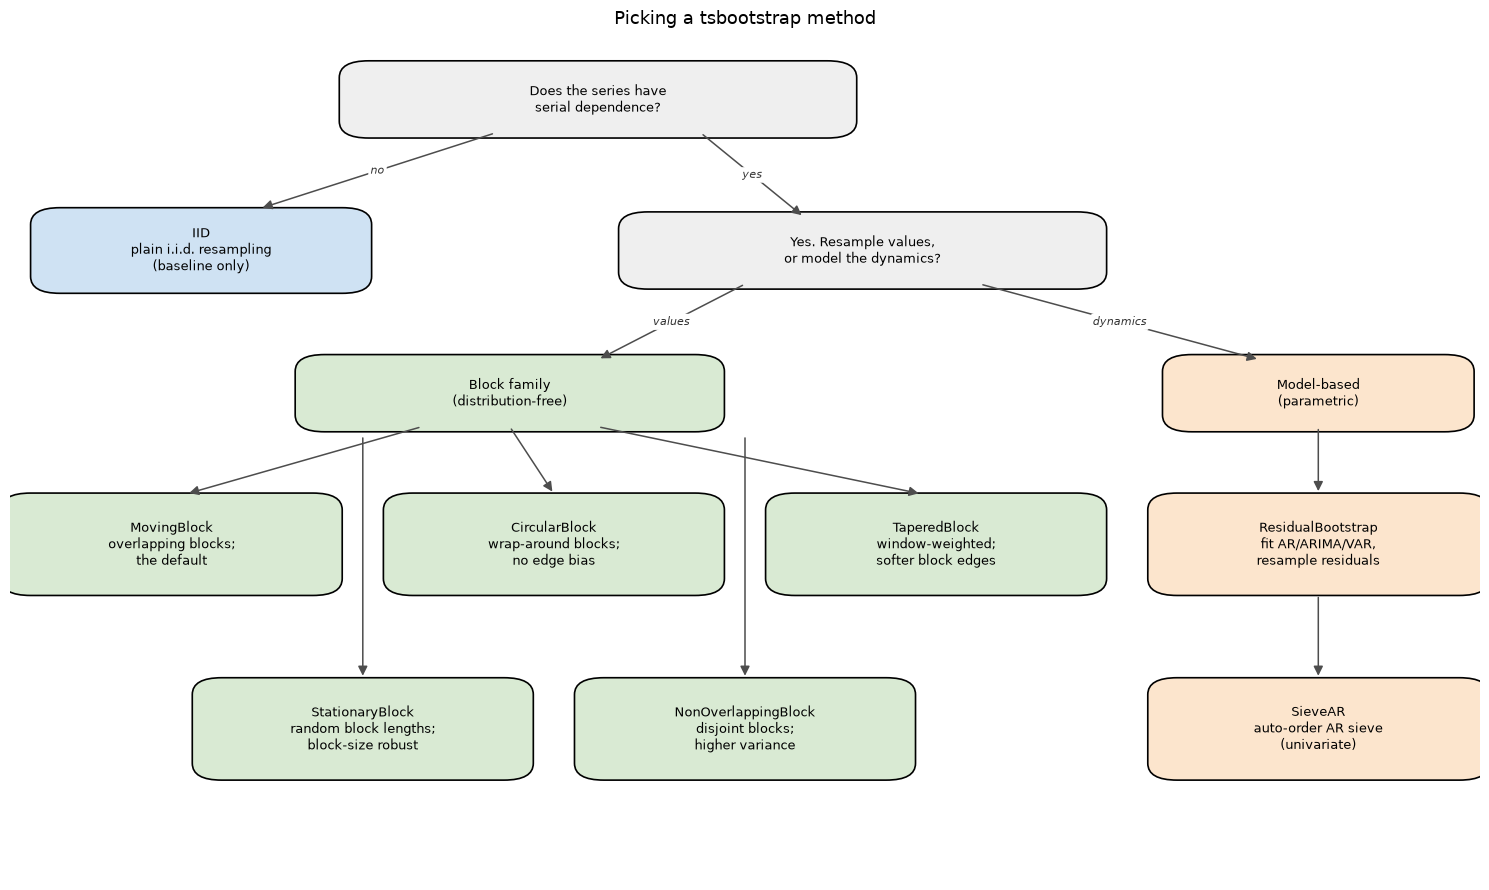

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis("off")


def box(x, y, w, h, text, color):
    """Draw a rounded box centered text and return its center point."""
    patch = FancyBboxPatch(
        (x - w / 2, y - h / 2),
        w,
        h,
        boxstyle="round,pad=0.6,rounding_size=2",
        linewidth=1.2,
        edgecolor="black",
        facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=9, wrap=True)
    return x, y


def arrow(p0, p1, label=None):
    """Draw an arrow from p0 to p1 with an optional mid-label."""
    ax.add_patch(
        FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=14, linewidth=1.1, color="0.3")
    )
    if label:
        mx, my = (p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2
        ax.text(
            mx,
            my,
            label,
            ha="center",
            va="center",
            fontsize=8,
            style="italic",
            color="0.2",
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none"},
        )


blue, green, orange, gray = "#cfe2f3", "#d9ead3", "#fce5cd", "#efefef"

# Top level: the first split.
root = box(40, 93, 34, 8, "Does the series have\nserial dependence?", gray)
iid = box(13, 75, 22, 9, "IID\nplain i.i.d. resampling\n(baseline only)", blue)
dep = box(58, 75, 32, 8, "Yes. Resample values,\nor model the dynamics?", gray)

# Second level: the two families, kept far apart on the x-axis.
block = box(34, 58, 28, 8, "Block family\n(distribution-free)", green)
model = box(89, 58, 20, 8, "Model-based\n(parametric)", orange)

# Block family children: a top row of three and a bottom row of two placed in
# the gaps below, all kept clear of the far-right model column.
mb = box(11, 40, 22, 11, "MovingBlock\noverlapping blocks;\nthe default", green)
cb = box(37, 40, 22, 11, "CircularBlock\nwrap-around blocks;\nno edge bias", green)
tb = box(63, 40, 22, 11, "TaperedBlock\nwindow-weighted;\nsofter block edges", green)
sb = box(24, 18, 22, 11, "StationaryBlock\nrandom block lengths;\nblock-size robust", green)
nb = box(50, 18, 22, 11, "NonOverlappingBlock\ndisjoint blocks;\nhigher variance", green)

# Model-based children, stacked in a dedicated far-right column (x = 89).
res = box(89, 40, 22, 11, "ResidualBootstrap\nfit AR/ARIMA/VAR,\nresample residuals", orange)
sv = box(89, 18, 22, 11, "SieveAR\nauto-order AR sieve\n(univariate)", orange)

# Top-level arrows.
arrow((33, 89), (17, 80), "no")
arrow((47, 89), (54, 79), "yes")
arrow((50, 71), (40, 62), "values")
arrow((66, 71), (85, 62), "dynamics")

# Block family to its children. The bottom-row connectors run straight down the
# clear gap columns so they never cross a top-row box.
arrow((28, 54), (12, 46))
arrow((34, 54), (37, 46))
arrow((40, 54), (62, 46))
arrow((24, 53), (24, 24))
arrow((50, 53), (50, 24))

# Model-based family to its children (within the far-right lane).
arrow((89, 54), (89, 46))
arrow((89, 34), (89, 24))

ax.set_title("Picking a tsbootstrap method", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## Confidence intervals in one call

`conf_int` reads a confidence interval for a statistic straight off a bootstrap run.
Pick `kind` by what you can assume:

- `percentile` / `basic`: distribution-free default, works with any method.
- `studentized`: second-order correct under dependence, works with any method.
- `bca`: skew-corrected, `IID` spec only.

`conf_int_panel` does the same per series over a ragged panel.

In [4]:
import numpy as np

from tsbootstrap import IID, MovingBlock, conf_int, conf_int_panel

series = np.random.default_rng(0).standard_normal(200)

# Distribution-free percentile interval for the mean, any method:
lo, hi, point = conf_int(
    series, "mean", method=MovingBlock(block_length="auto"), kind="percentile", alpha=0.1
)

# Second-order-correct studentized interval under dependence:
lo, hi, point = conf_int(
    series, "mean", method=MovingBlock(block_length="auto"), kind="studentized", alpha=0.1
)

# Skew-corrected BCa interval, i.i.d. data only:
lo, hi, point = conf_int(series, "mean", method=IID(), kind="bca", alpha=0.1)

# Per-series intervals over a ragged panel:
panel = [np.random.default_rng(i).standard_normal(n) for i, n in enumerate((120, 180, 90))]
lo, hi, point = conf_int_panel(
    panel, "mean", method=MovingBlock(block_length=10), kind="percentile", alpha=0.1
)
print("per-series percentile lower bounds:", np.round(lo, 3))

per-series percentile lower bounds: [-0.109 -0.159 -0.075]


## Where to go next

This table and tree are the static reference. Two pointers for using them:

- `diagnose` is the programmatic version of this table. It inspects your
  series (serial dependence, stationarity) and returns recommended method
  specifications. Treat it as a heuristic starting point, not a guarantee:

  ```python
  from tsbootstrap import diagnose
  diagnose(x).recommended_methods
  ```

- The which-bootstrap-when tutorial walks through the worked rationale: why
  one family beats another on a given series, and how block length and
  model order change the answer.